In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [27]:
INPUT_PATH = '/content/drive/MyDrive/y3s2/SRIP'
OUTPUT_PATH = '/content/drive/MyDrive/y3s2/SRIP/parquets'

#### The CSV files used are from Posthog views:

| Posthog view | CSV file | Description |
| -------- | -------- | -------- |
| events_with_study_sessions | Cohort2510.csv | All events from the 2510 cohort, with reconstructed study sessions |
| assignment_due_dates | AssignmentDueDates.csv | All course assignment due dates |


In [10]:
df = pd.read_csv(os.path.join(INPUT_PATH, 'Cohort2510.csv'))
assignments_df = pd.read_csv(os.path.join(INPUT_PATH, 'AssignmentDueDates.csv'))

## Adding features to df

Some features would take too long to include in Posthog's SQL editor. As such, they will be included in this notebook using Python.

### 1. Academic calendar weeks (`course_week`)
- Weeks are according to NUS AY25/26
- According to the timestamp column in df, add the corresponding `course_week`
- Enables grouping events by actual timelines that the course follows, instead of arbitrary calendar weeks

In [12]:
acad_calendar = [
    ('week_1',       '2026-01-12', '2026-01-18'),     ## original (nus) does not include weekends
    ('week_2',       '2026-01-19', '2026-01-25'),
    ('week_3',       '2026-01-26', '2026-02-01'),
    ('week_4',       '2026-02-02', '2026-02-08'),
    ('week_5',       '2026-02-09', '2026-02-15'),
    ('week_6',       '2026-02-16', '2026-02-22'),
    ('recess',       '2026-02-23', '2026-03-01'),
    ('week_7',       '2026-03-02', '2026-03-08'),
    ('week_8',       '2026-03-09', '2026-03-15'),
    ('week_9',       '2026-03-16', '2026-03-22'),
    ('week_10',      '2026-03-23', '2026-03-29'),
    ('week_11',      '2026-03-30', '2026-04-05'),
    ('week_12',      '2026-04-06', '2026-04-12'),
    ('week_13',      '2026-04-13', '2026-04-19'),
    ('reading',      '2026-04-20', '2026-04-24'),
    ('exam_1',       '2026-04-25', '2026-05-03'),
    ('exam_2',       '2026-05-04', '2026-05-09'),
]
cal_df = pd.DataFrame(acad_calendar, columns=['course_week', 'start', 'end'])
cal_df['start'] = pd.to_datetime(cal_df['start'])
cal_df['end'] = pd.to_datetime(cal_df['end'])

## Add course_week to df
df = df.sort_values('timestamp').reset_index(drop=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True).dt.tz_localize(None)
df['date'] = df['timestamp'].dt.normalize()

df = pd.merge_asof(
    df, cal_df[['start', 'course_week']].rename(columns={'start': 'date'}),
    on='date',
    direction='backward',
)


In [19]:
df['course_week'].value_counts()  ## Number of events that took place in each week

week_order = ['week_1', 'week_2', 'week_3', 'week_4', 'week_5', 'week_6', 'recess', 'week_7', 'week_8', 'week_9', 'week_10', 'week_11', 'week_12', 'week_13', 'reading', 'exam1', 'exam2']
df['course_week'] = pd.Categorical(df['course_week'], week_order)

### 2. `days_to_exercise` && `days_to_paper`
- `days_to_exercise`: The number of days left to an exercise's due date, from the event creation timestamp
- `days_to_paper`: The number of days left to a paper's due date, from the event creation timestamp

- Enables analysis of how different students' activity/behaviour patterns change as deadlines approach (e.g. last-minute cramming, sustained engagement throughout, drop offs after submission)

In [23]:
def classify(name):
    n = name.lower()
    if n.startswith('paper'):
        return 'paper'
    if n.startswith('ex'):
        return 'exercise'
    return 'other'

In [25]:
assignments_df['assignment'] = assignments_df['assignment'].apply(classify)
assignments_df['due_date'] = pd.to_datetime(assignments_df['due_date'])

exercise_due_dates = assignments_df.loc[assignments_df['assignment'] == 'exercise', 'due_date'].sort_values().reset_index(drop=True)
paper_due_dates = assignments_df.loc[assignments_df['assignment'] == 'paper', 'due_date'].sort_values().reset_index(drop=True)

# Find days until the NEXT exercise / paper due date
df['timestamp_date'] = df['timestamp'].dt.normalize()
df = df.sort_values('timestamp_date').reset_index(drop=True)

ex_lookup = pd.DataFrame({'due': exercise_due_dates}).sort_values('due')
paper_lookup = pd.DataFrame({'due': paper_due_dates}).sort_values('due')

# For each timestamp_date, find the smallest due_date >= event_date
df = pd.merge_asof(
    df, ex_lookup.rename(columns={'due': 'next_exercise_due'}),
    left_on='timestamp_date', right_on='next_exercise_due',
    direction='forward',
)
df = pd.merge_asof(
    df, paper_lookup.rename(columns={'due': 'next_paper_due'}),
    left_on='timestamp_date', right_on='next_paper_due',
    direction='forward',
)

df['days_to_exercise_due'] = (df['next_exercise_due'] - df['timestamp_date']).dt.days
df['days_to_paper_due'] = (df['next_paper_due'] - df['timestamp_date']).dt.days


### Save df with added features to parquet

In [29]:
df.to_parquet(os.path.join(OUTPUT_PATH, 'Cohort2510_with_features.parquet'))

## Create `weekly_activity` dataframe
- A per-student per-week aggregation of all events in the Cohort2510.csv
- Each student has a row for each academic week (`course_week`), with the fields:
| Field | Description |
| -------- | -------- |
| weekly_session_count | Number of study sessions in the week |
| avg_weekly_duration | Average duration of all study sessions in a week |
| prev_week_sessions | Previous week's number of study sessions |
| prev_week_duration | Previous week's average duration of study sessions |
| 3wk_avg_sessions | Average count of study sessions in the previous 3 weeks |
| 3wk_avg_duration | Average duration across study sessions in the previous 3 weeks  |

- Enables week-by-week comparisons of student engagement + makes visualizing unusual dips or spikes in activity across weeks/students easier

#### Limitations:

- **Study sessions are reconstructed:** Study sessions are inferred from gaps between event timestamps, not  reported by students. As such, a study session may not actually reflect a continuous period of study, from the student's perspective.

- **Duration may overestimate engagement:** The duration of a study session is treated as time spent studying, but students may have switched to other tabs/walked away from their laptop/left the page open while doing something else. (mitigated by tabFocused/tabUnfocused events)

- **No actual signal on whether students were actually engaging:** Session counts and durations only provide rough ideas of which materials students opened.


In [20]:
## For each student:
## 1. Get session count & average session duration over each week
weekly_activity = (
    df.groupby(['distinct_id', 'course_week'])
      .agg(
          weekly_session_count=('study_session_id', 'nunique'),
          avg_weekly_duration=('study_session_duration', 'mean'),
      )
      .reset_index()
)
weekly_activity = weekly_activity.sort_values(['distinct_id', 'course_week'])
grouped_wa = weekly_activity.groupby('distinct_id', group_keys=False)
## Some session_count and avg_weekly_duration values are 0 --> dividing to get avg will == NA
weekly_activity['avg_weekly_duration'] = weekly_activity['avg_weekly_duration'].fillna(0)

## 2. Get previous week's session count & avg session duration
weekly_activity['prev_week_sessions'] = grouped_wa['weekly_session_count'].shift(1)
weekly_activity['prev_week_duration'] = grouped_wa['avg_weekly_duration'].shift(1)

## 3. Get average of past 3 week's session count & avg session duration
weekly_activity['3wk_avg_sessions'] = (
    grouped_wa['weekly_session_count']
    .apply(lambda x: x.shift(1).rolling(window=3).mean())
    .reset_index(drop=True)
)
weekly_activity['3wk_avg_duration'] = (
    grouped_wa['avg_weekly_duration']
    .apply(lambda x: x.shift(1).rolling(window=3).mean())
    .reset_index(drop=True)
)

/tmp/ipykernel_4085/3142838878.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['distinct_id', 'course_week'])


In [21]:
print(weekly_activity.shape)
weekly_activity.head()

(408, 8)


,distinct_id,course_week,weekly_session_count,avg_weekly_duration,prev_week_sessions,prev_week_duration,3wk_avg_sessions,3wk_avg_duration
0,26,week_1,17,805.686667,NaN,NaN,NaN,NaN
1,26,week_2,8,1229.037736,17.0,805.686667,NaN,NaN
2,26,week_3,4,20.833333,8.0,1229.037736,NaN,NaN
3,26,week_4,5,660.863158,4.0,20.833333,9.666667,685.185912
4,26,week_5,7,1599.317073,5.0,660.863158,5.666667,636.911409


In [22]:
## Expected:
## - prev_week_* : 24 NA values
## - 3wk_avg_* : 24 students * 3 weeks = 72 NA values
for col in weekly_activity.columns:
    if weekly_activity[col].isna().sum() > 0:
        print(f'{col}: {weekly_activity[col].isna().sum()} NA values')

prev_week_sessions: 24 NA values
prev_week_duration: 24 NA values
3wk_avg_sessions: 72 NA values
3wk_avg_duration: 72 NA values


In [26]:
weekly_activity

,distinct_id,course_week,weekly_session_count,avg_weekly_duration,prev_week_sessions,prev_week_duration,3wk_avg_sessions,3wk_avg_duration
0,26,week_1,17,805.686667,NaN,NaN,NaN,NaN
1,26,week_2,8,1229.037736,17.0,805.686667,NaN,NaN
2,26,week_3,4,20.833333,8.0,1229.037736,NaN,NaN
3,26,week_4,5,660.863158,4.0,20.833333,9.666667,685.185912
4,26,week_5,7,1599.317073,5.0,660.863158,5.666667,636.911409
...,...,...,...,...,...,...,...,...
403,50,week_12,13,404.000000,18.0,2129.851282,14.333333,978.641841
404,50,week_13,8,110.491228,13.0,404.000000,13.333333,909.180730
405,50,reading,7,404.513889,8.0,110.491228,13.000000,881.447503
406,50,exam1,0,0.000000,7.0,404.513889,9.333333,306.335039


### Save weekly_activity to parquet

In [30]:
weekly_activity.to_parquet(os.path.join(OUTPUT_PATH, 'weekly_activity.parquet'))

## Graphs

The graphs that can be made using the dataframes here. May organize into other folders if necessary.

### 1. Session counts & durations over each course week

Cohort-wide baseline for # of study sessions + average duration across all weeks

Establishes baseline values for:
  - Which weeks were busiest/least busy
  - How session length shifted over the semester

To compare against individual student patterns and assignment due dates (deadline-driven activity, behavior patterns after deadlines)


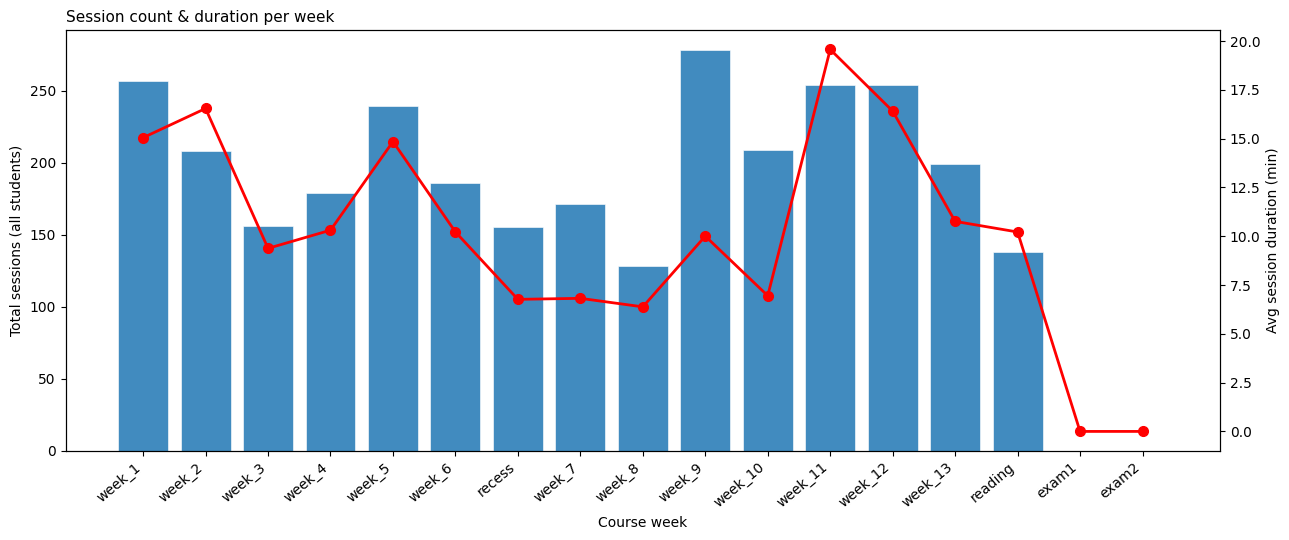

In [31]:
## Group by activity across all students --> totals for each week
week_totals = (
    weekly_activity
    .groupby('course_week', observed=True)
    .agg(
        total_sessions=('weekly_session_count', 'sum'),
        avg_duration=('avg_weekly_duration', 'mean'),
    )
    .reset_index()
)
week_totals = week_totals.sort_values('course_week').reset_index(drop=True)

## Convert duration from seconds to minutes
week_totals['avg_duration_min'] = week_totals['avg_duration'] / 60

fig, ax1 = plt.subplots(figsize=(13, 5.5))

## Bar chart for number of sessions
bars = ax1.bar(
    range(len(week_totals)),
    week_totals['total_sessions'],
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5,
)
ax1.set_xlabel('Course week')
ax1.set_ylabel('Total sessions (all students)')
ax1.set_xticks(range(len(week_totals)))
ax1.set_xticklabels(week_totals['course_week'], rotation=40, ha='right')

## Line for average total duration
ax2 = ax1.twinx()
ax2.plot(range(len(week_totals)), week_totals['avg_duration_min'],
         color='red', marker='o', linewidth=2, markersize=7, label='Avg duration')
ax2.set_ylabel('Avg session duration (min)')

plt.title('Session count & duration per week', fontsize=11, loc='left')
fig.tight_layout()
plt.show()